# Extracción de Texto OCR de Imágenes Secundarias

Este notebook utiliza PaddleOCR para extraer todo el texto de las imágenes secundarias de los productos y guardarlo en formato JSON.

## Objetivos
1. Cargar el dataset de productos
2. Descargar las imágenes secundarias
3. Aplicar PaddleOCR para extraer todo el texto
4. Guardar los resultados en JSON con el ID del producto

In [15]:
import polars as pl
import requests
from PIL import Image
from io import BytesIO
from pathlib import Path
import numpy as np
from tqdm.notebook import tqdm
from paddleocr import PaddleOCR
import json
import warnings
warnings.filterwarnings('ignore')

## 1. Configuración y Carga de Datos

In [16]:
# Configurar rutas
DATA_PATH = Path('../data/processed/products_macro.csv')
OUTPUT_JSON = Path('../data/processed/products_ocr_raw.json')

# Cargar datos
df = pl.read_csv(DATA_PATH)
print(f"Total de productos: {len(df)}")
print(f"Columnas: {df.columns}")
df.head()

Total de productos: 4793
Columnas: ['id', 'Category', 'name', 'subtitle', 'price', 'discount_price', 'main_image_url', 'secondary_image_url', 'nutritional_info', 'novedad']


id,Category,name,subtitle,price,discount_price,main_image_url,secondary_image_url,nutritional_info,novedad
i64,str,str,str,str,str,str,str,str,bool
1,"""Vacuno""","""Carpaccio de vacuno""","""Bandeja 110 g""","""4,10 €""",null,"""https://prod-mercadona.imgix.n…","""https://prod-mercadona.imgix.n…","""Carpaccio de vacuno, Bandeja, …",false
2,"""Vacuno""","""Filetes hígado de vacuno""","""Bandeja 440 g aprox.""","""4,58 €""",null,"""https://prod-mercadona.imgix.n…","""https://prod-mercadona.imgix.n…","""Filetes hígado de vacuno, Band…",false
3,"""Vacuno""","""Tacos de vacuno marinado para …","""Bandeja 600 g aprox.""","""9,72 €""",null,"""https://prod-mercadona.imgix.n…","""https://prod-mercadona.imgix.n…","""Tacos de vacuno marinado para …",false
4,"""Vacuno""","""Filetes de vacuno marinado ext…","""Bandeja 500 g aprox.""","""8,85 €""",null,"""https://prod-mercadona.imgix.n…","""https://prod-mercadona.imgix.n…","""Filetes de vacuno marinado ext…",false
5,"""Vacuno""","""Steak Tartar de vacuno marinad…","""Bandeja 200 g""","""5,40 €""",null,"""https://prod-mercadona.imgix.n…","""https://prod-mercadona.imgix.n…","""Steak Tartar de vacuno marinad…",false


In [17]:
# Filtrar productos que tienen imágenes secundarias
df_with_secondary = df.filter(
    (pl.col('secondary_image_url').is_not_null()) & 
    (pl.col('secondary_image_url') != '')
)

print(f"Productos con imagen secundaria: {len(df_with_secondary)}")
print(f"Porcentaje: {len(df_with_secondary)/len(df)*100:.2f}%")

Productos con imagen secundaria: 4676
Porcentaje: 97.56%


## 2. Inicializar PaddleOCR

In [18]:
# Inicializar PaddleOCR con soporte para español
ocr = PaddleOCR(lang='es')
print("✅ PaddleOCR inicializado correctamente")

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/computingvictor/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/computingvictor/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/computingvictor/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/computingvictor/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('latin_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory 

✅ PaddleOCR inicializado correctamente


## 3. Funciones de Procesamiento

In [19]:
def download_image(url, timeout=10):
    """
    Descarga una imagen desde una URL
    """
    try:
        response = requests.get(url, timeout=timeout)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content))
        return img
    except Exception as e:
        return None


def extract_text_from_image(img):
    """
    Extrae todo el texto de una imagen usando PaddleOCR
    Retorna una lista de diccionarios con el texto y confianza
    """
    try:
        # Convertir PIL Image a numpy array
        img_array = np.array(img)
        
        # Aplicar OCR
        result = ocr.predict(img_array)
        
        if result is None or len(result) == 0:
            return None
        
        # Extraer textos y confianzas
        page_result = result[0]
        texts = page_result.get('rec_texts', [])
        scores = page_result.get('rec_scores', [])
        polys = page_result.get('dt_polys', [])
        
        # Crear lista con todos los datos
        ocr_data = []
        for text, confidence, bbox in zip(texts, scores, polys):
            ocr_data.append({
                'text': text,
                'confidence': float(confidence),
                'bbox': bbox.tolist() if hasattr(bbox, 'tolist') else bbox
            })
        
        return ocr_data
    
    except Exception as e:
        print(f"Error en OCR: {str(e)}")
        return None


print("✅ Funciones definidas")

✅ Funciones definidas


## 4. Prueba con una imagen

Producto: Carpaccio de vacuno
ID: 1
URL: https://prod-mercadona.imgix.net/images/baaca712fb6ea1078afa60063293e6fd.jpg?fit=crop&h=600&w=600

✅ Imagen descargada: (600, 600)


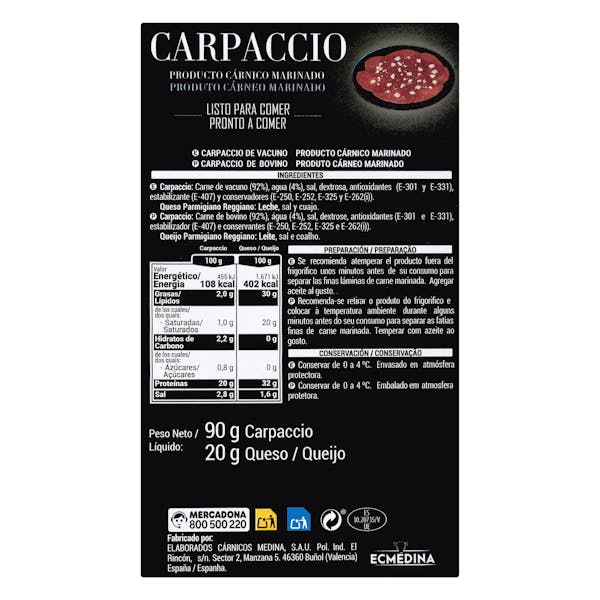


✅ Texto extraído: 71 elementos

Textos detectados:
1. CARPACCIO (confianza: 99.98%)
2. PRODUCTO CÁRNICO MARINADO (confianza: 96.86%)
3. PRODUTO CÁRNEO MARINADO (confianza: 97.42%)
4. LISTO PARA COMER (confianza: 95.49%)
5. PRONTO A COMER (confianza: 99.15%)
6. © CARPACCIO DE VACUNO (confianza: 94.25%)
7. PRODUCTO CÁRNICO MARINADO (confianza: 99.68%)
8. © CARPACCIO DE BOVINO PRODUTO CÁRNEO MARINADO (confianza: 98.42%)
9. INGREDIENTES (confianza: 95.46%)
10. Carpaccie: Came de vacuno (92%), agua (4%), sal, dextrosa, anticoidantes (E-301 y E-331). (confianza: 93.41%)
... y 61 más


In [20]:
# Probar con la primera imagen
sample = df_with_secondary.head(1)

for row in sample.iter_rows(named=True):
    product_id = row['id']
    product_name = row['name']
    img_url = row['secondary_image_url']
    
    print(f"Producto: {product_name}")
    print(f"ID: {product_id}")
    print(f"URL: {img_url}\n")
    
    # Descargar imagen
    img = download_image(img_url)
    if img is None:
        print("❌ No se pudo descargar la imagen")
        continue
    
    print(f"✅ Imagen descargada: {img.size}")
    display(img)
    
    # Extraer texto
    ocr_result = extract_text_from_image(img)
    
    if ocr_result:
        print(f"\n✅ Texto extraído: {len(ocr_result)} elementos\n")
        print("Textos detectados:")
        for i, item in enumerate(ocr_result[:10]):  # Mostrar solo los primeros 10
            print(f"{i+1}. {item['text']} (confianza: {item['confidence']:.2%})")
        
        if len(ocr_result) > 10:
            print(f"... y {len(ocr_result) - 10} más")
    else:
        print("❌ No se pudo extraer texto")

## 5. Configuración de Procesamiento

In [21]:
# Configuración
PROCESS_ALL = True  # Cambiar a True para procesar todos los productos
MAX_PRODUCTS = 100   # Número máximo de productos a procesar (si PROCESS_ALL = False)

if PROCESS_ALL:
    products_to_process = df_with_secondary
else:
    products_to_process = df_with_secondary.head(MAX_PRODUCTS)

print(f"Se procesarán {len(products_to_process)} productos")

Se procesarán 4676 productos


## 6. Procesamiento de todas las imágenes

In [ ]:
# Procesar todas las imágenes
results = []
errors = []

for row in tqdm(products_to_process.iter_rows(named=True), total=len(products_to_process)):
    product_id = row['id']
    product_name = row['name']
    category = row['Category']
    img_url = row['secondary_image_url']
    
    try:
        # Descargar imagen
        img = download_image(img_url)
        if img is None:
            errors.append({
                'product_id': product_id,
                'error': 'Failed to download image'
            })
            continue
        
        # Extraer texto con OCR
        ocr_data = extract_text_from_image(img)
        
        if ocr_data is None:
            errors.append({
                'product_id': product_id,
                'error': 'OCR failed'
            })
            continue
        
        # Guardar resultado
        result = {
            'product_id': product_id,
            'product_name': product_name,
            'category': category,
            'image_url': img_url,
            'ocr_data': ocr_data,
            'total_texts': len(ocr_data),
            'avg_confidence': np.mean([item['confidence'] for item in ocr_data])
        }
        
        results.append(result)
    
    except Exception as e:
        errors.append({
            'product_id': product_id,
            'error': str(e)
        })

print(f"\n✅ Procesamiento completado")
print(f"   Exitosos: {len(results)}")
print(f"   Errores: {len(errors)}")

  0%|          | 0/4676 [00:00<?, ?it/s]

## 7. Guardar Resultados en JSON

In [ ]:
# Guardar resultados en JSON
with open(OUTPUT_JSON, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(f"✅ Resultados guardados en: {OUTPUT_JSON}")
print(f"   Total de productos: {len(results)}")
print(f"   Tamaño del archivo: {OUTPUT_JSON.stat().st_size / 1024 / 1024:.2f} MB")

# Guardar errores si los hay
if errors:
    errors_path = OUTPUT_JSON.parent / 'products_ocr_errors.json'
    with open(errors_path, 'w', encoding='utf-8') as f:
        json.dump(errors, f, ensure_ascii=False, indent=2)
    print(f"\n⚠️  Errores guardados en: {errors_path}")

## 8. Visualizar Resultados

In [ ]:
# Estadísticas
import pandas as pd
import matplotlib.pyplot as plt

# Crear DataFrame para análisis
stats_data = [{
    'product_id': r['product_id'],
    'product_name': r['product_name'],
    'category': r['category'],
    'total_texts': r['total_texts'],
    'avg_confidence': r['avg_confidence']
} for r in results]

df_stats = pd.DataFrame(stats_data)

print("📊 Estadísticas de OCR")
print("="*60)
print(f"Total productos procesados: {len(df_stats)}")
print(f"Textos detectados (promedio): {df_stats['total_texts'].mean():.1f}")
print(f"Textos detectados (mediana): {df_stats['total_texts'].median():.1f}")
print(f"Confianza promedio: {df_stats['avg_confidence'].mean():.2%}")
print(f"\nTop 10 productos con más texto:")
print(df_stats.nlargest(10, 'total_texts')[['product_name', 'total_texts', 'avg_confidence']])

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de cantidad de textos
axes[0].hist(df_stats['total_texts'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de Cantidad de Textos Detectados', fontweight='bold')
axes[0].set_xlabel('Número de textos')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(True, alpha=0.3)

# Histograma de confianza
axes[1].hist(df_stats['avg_confidence'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Distribución de Confianza del OCR', fontweight='bold')
axes[1].set_xlabel('Confianza promedio')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Ejemplo de un resultado

In [ ]:
# Mostrar un ejemplo completo
if results:
    example = results[0]
    print("Ejemplo de resultado completo:")
    print("="*60)
    print(f"Product ID: {example['product_id']}")
    print(f"Nombre: {example['product_name']}")
    print(f"Categoría: {example['category']}")
    print(f"Total textos: {example['total_texts']}")
    print(f"Confianza promedio: {example['avg_confidence']:.2%}")
    print(f"\nPrimeros 5 textos:")
    for i, item in enumerate(example['ocr_data'][:5]):
        print(f"{i+1}. {item['text']} (confianza: {item['confidence']:.2%})")
    
    print(f"\nJSON completo (truncado):")
    print(json.dumps(example, ensure_ascii=False, indent=2)[:500] + "...")

## 10. Resumen

Este notebook ha extraído todo el texto de las imágenes secundarias usando PaddleOCR.

### Estructura del JSON de salida:

```json
[
  {
    "product_id": 1,
    "product_name": "Nombre del producto",
    "category": "Categoría",
    "image_url": "https://...",
    "ocr_data": [
      {
        "text": "Texto detectado",
        "confidence": 0.95,
        "bbox": [[x1,y1], [x2,y2], [x3,y3], [x4,y4]]
      },
      ...
    ],
    "total_texts": 67,
    "avg_confidence": 0.92
  },
  ...
]
```

### Archivos generados:
- `products_ocr_raw.json`: Todos los resultados OCR
- `products_ocr_errors.json`: Productos que fallaron (si los hay)